# **LRAC-7112** - Implement a version of Dichotomous metrics (AB Testing) using pymc3

---

Implement the posterior sampling of the Dichotomous metrics of the AB Testing algorithm using pymc3 to make sure that we have a usable and testable version of the algorithm in python. 


## Installing `arviz` for plotting

In [ ]:
pip install -q arviz

# Installing `pymc3` version 3.8 (required for arviz plotting)

In [ ]:
pip install -q pymc3==3.8

In [ ]:
import numpy as np
import pandas as pd
import pymc3 as pm
import arviz as az
import matplotlib.pyplot as plt
import scipy.stats as stats
import unittest

In [ ]:
dataset = pd.DataFrame(data={
    'trials':[3025,2895,3200,3523,2065,1645],
    'successes':[2235,2132,1789,3002,1245,1135],
    'days':[1,2,1,2,1,2]
},
index=['Control','Control','Variant A','Variant A','Variant B','Variant B']
)

dataset

,trials,successes,days
Control,3025,2235,1
Control,2895,2132,2
Variant A,3200,1789,1
Variant A,3523,3002,2
Variant B,2065,1245,1
Variant B,1645,1135,2


In [ ]:
groups = dataset.groupby(dataset.index).agg({'trials':'sum', 'successes':'sum'})
groups

,trials,successes
Control,5920,4367
Variant A,6723,4791
Variant B,3710,2380


In [ ]:
probs = groups.assign(rate = lambda df: df['successes']/df['trials'])['rate']
probs

Control      0.737669
Variant A    0.712628
Variant B    0.641509
Name: rate, dtype: float64

# MCMC Model

For this demostration, the model is a functions that takes the following parameters:

* `probs`: a list of probabilities (floats between 0 and 1)
* `observed_values`: a list of numpy arrays of type int (0 and 1) simulating arrays of Dichotomous observed values (Clicks or Bounces)
* `draws`: Int that configures the number of times that we are going to sample for the posterior distributions via MCMC sampling.

The function returns a `pymc3.backends.base.MultiTrace`object that has the actual posterior distributions and other stats and data.

---

# The `pymc3` syntax

Basically, all that is needed for this implementation is to instantiate a `pymc3` model and add the stochastic variables to the model, one *prior probability distribution* and one *likelihood function* for each of the variants.

# The Model

One should add the variables to a `pymc3` model object using the `context manager`. So, you start with a `with pm.Model() as name_of_the_model:` and everything that you declare inside this block is added to the model. For the Dichotomous model, all that is needed is a prior Uniform for the Control group and one for each one of the Variants and one Bernoulli distribution for each one of the priors and the arrays of observed values.


In [ ]:
def run_mcmc_model(probs, observed_values, draws=10000):
  observed_control, *observed_variants = observed_values

  with pm.Model() as model:

    prior_control = pm.Uniform(name='Control prior', lower=0., upper=1.)
    pm.Bernoulli(name='likelihood_control', p=prior_control,
                 observed=observed_control)
    
    deltas = []
    for i, prob in enumerate(probs[1:]):
      temp_prior_variant = pm.Uniform(name=f'Variant {chr(i+65)} prior',
                                      lower=0., upper=1.)
      pm.Bernoulli(name=f'likelihood variant {chr(i+65)}', p=temp_prior_variant,
                   observed=obs_variants[i])
      
      deltas.append({f'Delta of Control - Variant {chr(i+65)}': pm.Deterministic(
          f'delta C - {chr(i+65)}', prior_control - temp_prior_variant
      )})
    trace = pm.sample(draws,chains=5)

  return trace

In [ ]:
N = 3000
obs_control = stats.bernoulli.rvs(p=probs[0], size=N, random_state=42)
obs_variants = []

for i, prob in enumerate(probs[1:]):
  obs_variants.append(
      stats.bernoulli.rvs(p=prob, size=N, random_state=42)
  )

In [ ]:
mcmc_result = run_mcmc_model(probs.tolist(), [obs_control, obs_variants])

# Plotting the results

/usr/local/lib/python3.6/dist-packages/arviz/data/io_pymc3.py:91: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  FutureWarning,


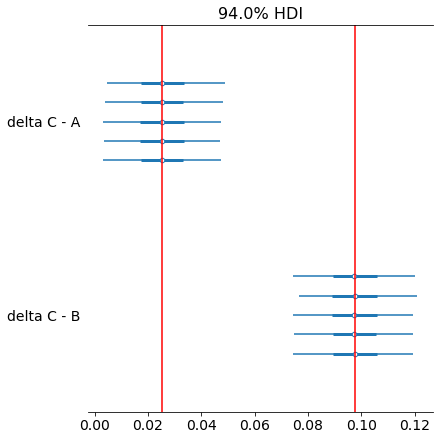

In [ ]:
delta_c_a_mean = mcmc_result['delta C - A'].mean()
delta_c_b_mean = mcmc_result['delta C - B'].mean()

az.plot_forest(mcmc_result, var_names=['delta C - A', 'delta C - B'])
plt.axvline(delta_c_a_mean, color='r')
plt.axvline(delta_c_b_mean, color='r')
plt.show()

/usr/local/lib/python3.6/dist-packages/arviz/data/io_pymc3.py:91: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  FutureWarning,


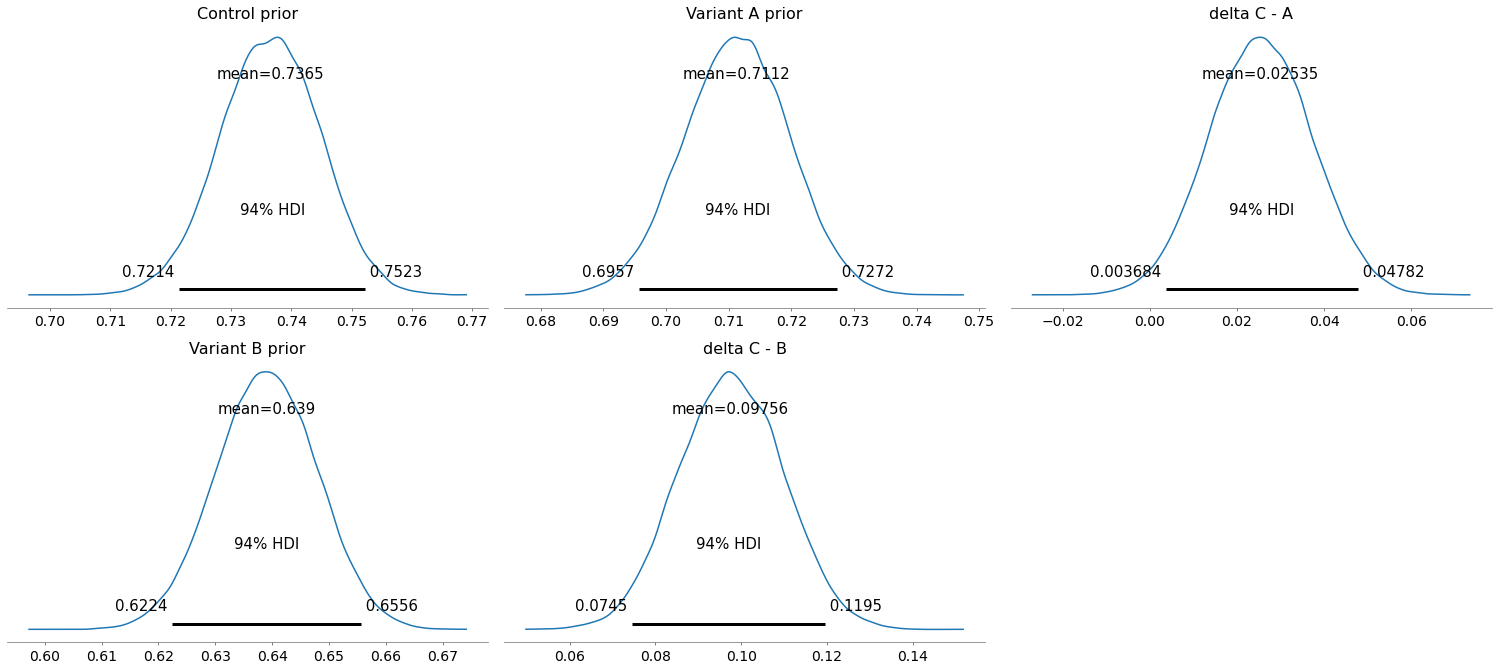

In [ ]:
az.plot_posterior(mcmc_result, round_to=4)
plt.show()